<a href="https://colab.research.google.com/github/Teapot-t/kurs-Uczenie-Maszynowe/blob/main/zadanie_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Założenia zadania
zadana funkcja straty - entropia krzyżowa
$$
L(y, z) = -y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z)),
$$
- $y_i \in \{0,1\}$ zmienne binarne,
- $\sigma(z) = \frac{1}{1 + e^{-z}}$  sigmoid.
- **zadane stałe dotyczące danych: $m$ (liczba jedynek) and $k$ (liczba zer)**.
- losowo zadane poprzednie predyckje z poprzedniego kroku $f_i = f_{m-1}(x_i)$ wygenerowane z rozkładu normalnego



# Analiza przypadku A - analitycznie szukamy prostego (stałego) predyktora do klasyfikacji tego zbioru danych

Czyli minimalizujemy $λ^*$ zadane jako:
$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, \lambda).
$$
szukając $λ^*$ różniczkujemy $L$ po $λ$ (zaczynamy od pojedynczej składowej sumy):
$$
\frac{d}{dλ}L(y,Λ) = -y ⋅ \frac{1}{σ(λ)}⋅σ'(λ) - (1-y)\frac{1}{1-σ(λ)}⋅σ'(λ)
$$
musimy się przyjżeć własności funkcji $σ$, skorzystamy z własności:
$$ σ'(x) = σ(x)(1-σ(x)) $$
Wtedy nasza pochodna nabiera postaci:
$$
\frac{d}{dλ}L(y,λ) = -y ⋅ (1-σ(λ)) + (1-y)σ(λ) = σ(λ) - y
$$
z addytywności, przyrównujemy do zera i korzystamy ze znajomości liczby klas ($∑y_i = m$):
$$
0 = \frac{d}{dλ} \sum_{0}^{n} (σ(λ)-y_i) = nσ(λ)-m
$$
$$
\sigma(λ^*) = \frac{m}{n}
$$
sigmoid jest różnowartościowy więc odwracalny zatem dostajemy:
$$
λ^*=\log\left(\frac{\frac{m}{n}}{1-\frac{m}{n}}\right)= log(\frac{m}{k})
$$
Zatem naszym optymalnym predyktorem prostym jest log-likelyhood oparty o liczność klas w zbiorze danych i ma on prostą i interpretowalną postać


# Przypadek B - mamy do czynienia z "szumem losowym" poprzednich predyktorów
stosujemy analogiczną strategię i wykonujemy analogiczne obliczenia otrzymując
$$
\sum_0^n σ(f_i+λ) = m
$$
funkcja sigmoidalna jest jednak bardzo nieliniowa i nie ma "ładnych" addytywnych własności nie możemy więc analitycznie odwikłać wartości optymalnego $λ$ z otrzymanej sumy co generuje problemy. (zwłaszcza, że f_i zdecydowanie nie są jednakowe ani nie mają ułatwiającej zadania struktury gdyż pochodzą z rozkładu normalnego)

# Część pythonowa z wykresami

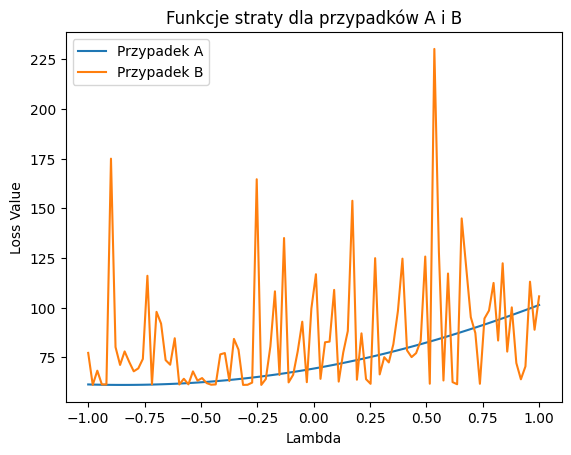

In [9]:
import numpy as np
import matplotlib.pyplot as plt
n = 100
m = 30
k = 70
y = np.array([1]*m + [0]*k)
f = np.random.normal(size = n)
lambdas = np.linspace(-1,1,100)
fl = f + lambdas
def sigma(z):
  return 1/(1+np.exp(-z))
def loss(y, l):
  return np.sum(-y*np.log(sigma(l))-(1-y)*np.log(1-sigma(l)))
lossvaluesA = np.array([loss(y, l) for l in lambdas])
lossvaluesB = np.array([loss(y, l) for l in fl])
plt.plot(lambdas, lossvaluesA, label='Przypadek A')
plt.plot(lambdas, lossvaluesB, label='Przypadek B')
plt.legend()
plt.xlabel('Lambda')
plt.ylabel('Loss Value')
plt.title('Funkcje straty dla przypadków A i B')
plt.show()

Jak widać na wykresie, dodanie szumu losowego jako $m-1$-tej predykcji całkowicie zaburza strukturę problemu. Nawet numeryczne metody szukania minimów lokalnych w tym przypadku mogą nie dać rady ze względu na brak jakiejkolwiek regularności w zachowaniu funkcji - tak wiele minimów lokalnych może zatrzymać gradient descent w złym punkcie albo trafiając w liczne miejsca z wysokimi gradientami możemy trafić na problem w ogóle ze zbieganiem w odpowiednim kierunku i magnitudzie. Eksperyment pokazuje, że w przypadku FASM mając bardzo zły predyktor lepszym rozwiązaniem może być utworzenie nowego bardziej niż dodawanie kolejnego etapu.


Z drugiej strony, tak jak pokazaliśmy że taka sytuacja jest możliwa przy celowej konstrukcji, można się zastanawiać, czy może się ona pojawić w tak dużym stopniu w naturalny sposób. FASM wybiera optymalne małe predyktory w każdym kroku więc można oczekiwać, że $m-1$ predyktor nie będzie obarczony tak dużym szumem jak całkowicie losowy i będzie miał lepszy performance.